# Project 1 — Titanic Survival Prediction

**Type:** Binary Classification  
**Dataset:** Titanic passenger data  
**Goal:** Predict whether a passenger survived the Titanic disaster

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/himanshu231204/ml-mastery/blob/main/03_projects/titanic/titanic.ipynb)

---

## Table of Contents
1. [Problem Statement](#1-problem-statement)
2. [Load and Inspect Data](#2-load-and-inspect-data)
3. [Exploratory Data Analysis (EDA)](#3-exploratory-data-analysis)
4. [Feature Engineering](#4-feature-engineering)
5. [Build Preprocessing Pipeline](#5-build-preprocessing-pipeline)
6. [Train and Compare Models](#6-train-and-compare-models)
7. [Hyperparameter Tuning](#7-hyperparameter-tuning)
8. [Final Model Evaluation](#8-final-model-evaluation)
9. [Feature Importance and Insights](#9-feature-importance-and-insights)
10. [Key Takeaways](#10-key-takeaways)


## 1. Problem Statement

The Titanic sank on April 15, 1912 after colliding with an iceberg. Of the 2,224 passengers and crew, 1,502 died. The survival was not random — women, children, and upper-class passengers had a significantly higher survival rate.

**Task:** Binary classification — predict `Survived` (0 = No, 1 = Yes)

**Evaluation metric:** Accuracy (balanced classes after feature engineering)

**Features available:**

| Feature | Description | Type |
|---|---|---|
| `Pclass` | Ticket class (1st, 2nd, 3rd) | Ordinal |
| `Name` | Passenger name | Text — extract title |
| `Sex` | Gender | Categorical |
| `Age` | Age in years | Numeric, has missing values |
| `SibSp` | Number of siblings/spouses aboard | Numeric |
| `Parch` | Number of parents/children aboard | Numeric |
| `Ticket` | Ticket number | Text — ignore |
| `Fare` | Passenger fare | Numeric, skewed |
| `Cabin` | Cabin number | Text, mostly missing |
| `Embarked` | Port of embarkation (C/Q/S) | Categorical |


## 2. Load and Inspect Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

# Load from sklearn or seaborn (no file needed)
from sklearn.datasets import fetch_openml
titanic_raw = fetch_openml('titanic', version=1, as_frame=True, parser='auto')
df = titanic_raw.frame.copy()

# Standardize column names and target
df.columns = [c.lower() for c in df.columns]
df['survived'] = df['survived'].astype(int)

# Keep relevant columns
cols = ['survived','pclass','name','sex','age','sibsp','parch','fare','cabin','embarked']
df   = df[cols].copy()

print(f'Shape: {df.shape}')
print(f'\nFirst 5 rows:')
df.head()


Shape: (1309, 10)

First 5 rows:


,survived,pclass,name,sex,age,sibsp,parch,fare,cabin,embarked
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,211.3375,B5,S
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,151.5500,C22 C26,S
2,0,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,151.5500,C22 C26,S
3,0,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,151.5500,C22 C26,S
4,0,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,151.5500,C22 C26,S


In [2]:
print('Dataset info:')
df.info()
print('\nMissing values:')
print(df.isnull().sum())
print(f'\nTarget distribution:')
print(df['survived'].value_counts())
print(f'Survival rate: {df["survived"].mean():.3f}')


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   survived  1309 non-null   int64   
 1   pclass    1309 non-null   int64   
 2   name      1309 non-null   object  
 3   sex       1309 non-null   category
 4   age       1046 non-null   float64 
 5   sibsp     1309 non-null   int64   
 6   parch     1309 non-null   int64   
 7   fare      1308 non-null   float64 
 8   cabin     295 non-null    object  
 9   embarked  1307 non-null   category
dtypes: category(2), float64(2), int64(4), object(2)
memory usage: 84.7+ KB

Missing values:
survived       0
pclass         0
name           0
sex            0
age          263
sibsp          0
parch          0
fare           1
cabin       1014
embarked       2
dtype: int64

Target distribution:
survived
0    809
1    500
Name: count, dtype: int64
Survival rate: 0.382


In [3]:
print('Numeric summary:')
df.describe().round(2)


Numeric summary:


,survived,pclass,age,sibsp,parch,fare
count,1309.00,1309.00,1046.00,1309.00,1309.00,1308.00
mean,0.38,2.29,29.88,0.50,0.39,33.30
std,0.49,0.84,14.41,1.04,0.87,51.76
min,0.00,1.00,0.17,0.00,0.00,0.00
25%,0.00,2.00,21.00,0.00,0.00,7.90
50%,0.00,3.00,28.00,0.00,0.00,14.45
75%,1.00,3.00,39.00,1.00,0.00,31.28
max,1.00,3.00,80.00,8.00,9.00,512.33


## 3. Exploratory Data Analysis

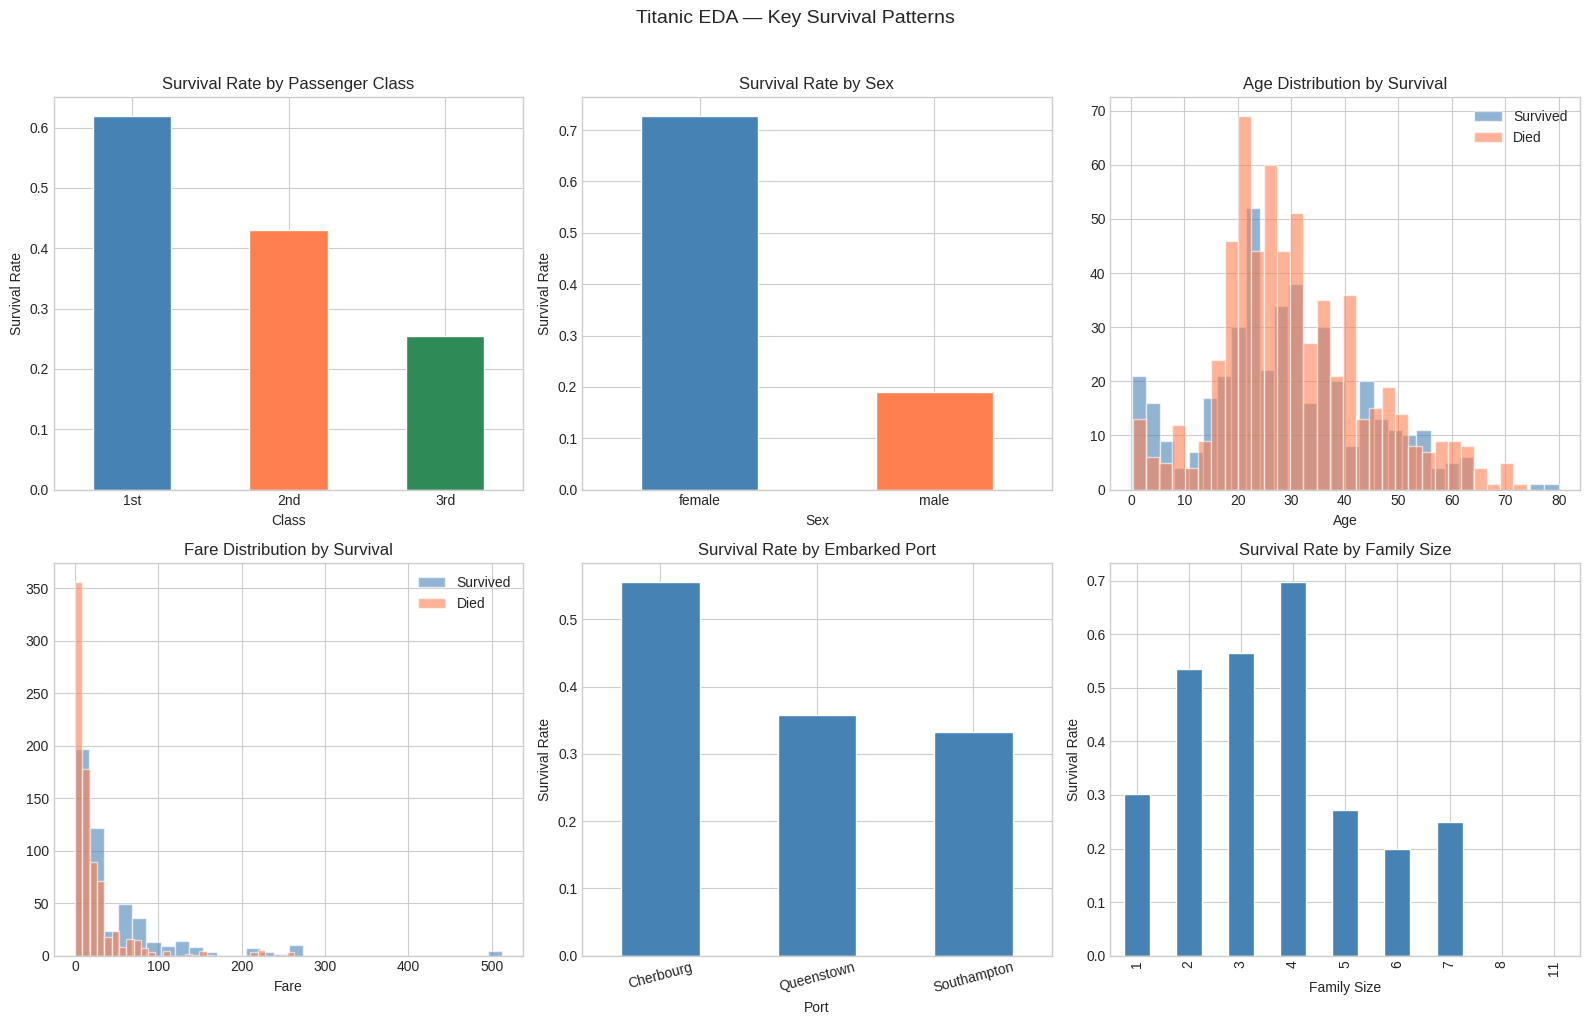

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Survival rate by Pclass
df.groupby('pclass')['survived'].mean().plot.bar(
    ax=axes[0,0], color=['steelblue','coral','seagreen'], edgecolor='white')
axes[0,0].set_title('Survival Rate by Passenger Class')
axes[0,0].set_xlabel('Class'); axes[0,0].set_ylabel('Survival Rate')
axes[0,0].set_xticklabels(['1st','2nd','3rd'], rotation=0)

# Survival rate by Sex
df.groupby('sex')['survived'].mean().plot.bar(
    ax=axes[0,1], color=['steelblue','coral'], edgecolor='white')
axes[0,1].set_title('Survival Rate by Sex')
axes[0,1].set_xlabel('Sex'); axes[0,1].set_ylabel('Survival Rate')
axes[0,1].set_xticklabels(df.groupby('sex')['survived'].mean().index, rotation=0)

# Age distribution by survival
df[df['survived']==1]['age'].dropna().hist(ax=axes[0,2], bins=30,
    alpha=0.6, color='steelblue', label='Survived', edgecolor='white')
df[df['survived']==0]['age'].dropna().hist(ax=axes[0,2], bins=30,
    alpha=0.6, color='coral', label='Died', edgecolor='white')
axes[0,2].set_title('Age Distribution by Survival')
axes[0,2].set_xlabel('Age'); axes[0,2].legend()

# Fare distribution (log scale)
df[df['survived']==1]['fare'].dropna().hist(ax=axes[1,0], bins=30,
    alpha=0.6, color='steelblue', label='Survived', edgecolor='white')
df[df['survived']==0]['fare'].dropna().hist(ax=axes[1,0], bins=30,
    alpha=0.6, color='coral', label='Died', edgecolor='white')
axes[1,0].set_title('Fare Distribution by Survival')
axes[1,0].set_xlabel('Fare'); axes[1,0].legend()

# Survival by Embarked
df.groupby('embarked')['survived'].mean().plot.bar(
    ax=axes[1,1], color='steelblue', edgecolor='white')
axes[1,1].set_title('Survival Rate by Embarked Port')
axes[1,1].set_xlabel('Port'); axes[1,1].set_ylabel('Survival Rate')
axes[1,1].set_xticklabels(['Cherbourg','Queenstown','Southampton'], rotation=15)

# SibSp + Parch combined
df['family_size'] = df['sibsp'] + df['parch'] + 1
df.groupby('family_size')['survived'].mean().plot.bar(
    ax=axes[1,2], color='steelblue', edgecolor='white')
axes[1,2].set_title('Survival Rate by Family Size')
axes[1,2].set_xlabel('Family Size'); axes[1,2].set_ylabel('Survival Rate')

plt.suptitle('Titanic EDA — Key Survival Patterns', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


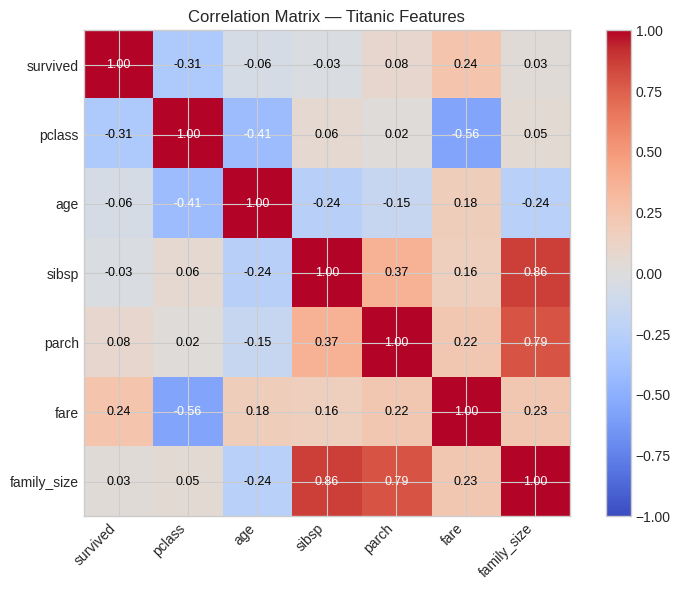

In [5]:
# Correlation heatmap of numeric features
numeric_df = df[['survived','pclass','age','sibsp','parch','fare','family_size']].copy()
corr        = numeric_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
cols_c = corr.columns.tolist()
ax.set_xticks(range(len(cols_c))); ax.set_yticks(range(len(cols_c)))
ax.set_xticklabels(cols_c, rotation=45, ha='right')
ax.set_yticklabels(cols_c)
for i in range(len(cols_c)):
    for j in range(len(cols_c)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center',
                fontsize=9, color='white' if abs(corr.iloc[i,j])>0.4 else 'black')
ax.set_title('Correlation Matrix — Titanic Features', fontsize=12)
plt.tight_layout()
plt.show()


## 4. Feature Engineering

Key engineered features based on EDA:

- **Title** — extracted from name (Mr, Mrs, Miss, Master, Rare) — strong survival predictor
- **FamilySize** — sibsp + parch + 1 — non-linear relationship with survival
- **IsAlone** — binary flag for solo travelers
- **CabinKnown** — binary flag for whether cabin was recorded (proxy for class)
- **FareBin** — fare grouped into quantile bins to reduce outlier impact
- **AgeBin** — age grouped into life-stage bins


In [6]:
def engineer_features(df):
    df = df.copy()

    # Extract title from name
    df['title'] = df['name'].str.extract(r',\s([A-Za-z]+)\.')
    rare_titles = df['title'].value_counts()
    rare_titles = rare_titles[rare_titles < 10].index
    df['title'] = df['title'].replace(rare_titles, 'Rare')
    df['title'] = df['title'].replace({
        'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'
    })

    # Family features
    df['family_size'] = df['sibsp'] + df['parch'] + 1
    df['is_alone']    = (df['family_size'] == 1).astype(int)

    # Cabin known
    df['cabin_known'] = df['cabin'].notna().astype(int)

    # Log fare (reduce skew)
    df['fare_log'] = np.log1p(df['fare'].fillna(df['fare'].median()))

    # Age bins
    df['age_bin'] = pd.cut(df['age'],
                           bins=[0, 12, 18, 35, 60, 100],
                           labels=['child','teen','young_adult','adult','senior'],
                           right=True)

    # Fare bins
    df['fare_bin'] = pd.qcut(df['fare'].fillna(df['fare'].median()),
                              q=4, labels=['low','mid','high','very_high'],
                              duplicates='drop')

    return df

df = engineer_features(df)

print('New features added:')
print(df[['title','family_size','is_alone','cabin_known','fare_log','age_bin','fare_bin']].head(10))


New features added:
    title  family_size  is_alone  cabin_known  fare_log      age_bin  \
0    Miss            1         1            1  5.358177  young_adult   
1  Master            4         0            1  5.027492        child   
2    Miss            4         0            1  5.027492        child   
3      Mr            4         0            1  5.027492  young_adult   
4     Mrs            4         0            1  5.027492  young_adult   
5      Mr            1         1            1  3.316003        adult   
6    Miss            2         0            1  4.368920       senior   
7      Mr            1         1            1  0.000000        adult   
8     Mrs            3         0            1  3.960417        adult   
9      Mr            1         1            0  3.922057       senior   

    fare_bin  
0  very_high  
1  very_high  
2  very_high  
3  very_high  
4  very_high  
5       high  
6  very_high  
7        low  
8  very_high  
9  very_high  


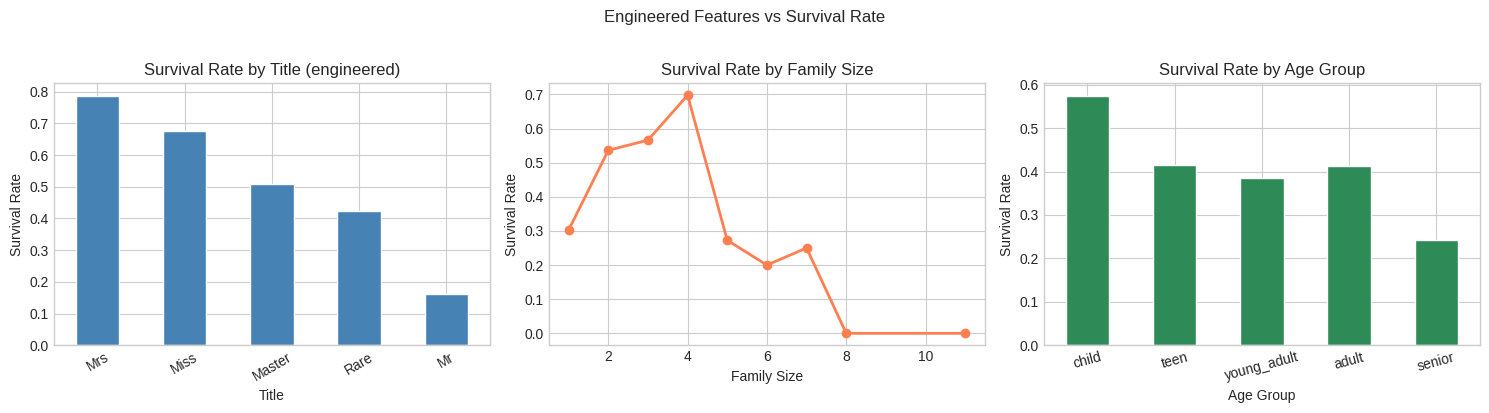

In [7]:
# Verify engineered features are useful
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Title vs survival
title_surv = df.groupby('title')['survived'].mean().sort_values(ascending=False)
title_surv.plot.bar(ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Survival Rate by Title (engineered)')
axes[0].set_xlabel('Title'); axes[0].set_ylabel('Survival Rate')
axes[0].tick_params(axis='x', rotation=30)

# Family size vs survival
df.groupby('family_size')['survived'].mean().plot(
    ax=axes[1], color='coral', marker='o', linewidth=2)
axes[1].set_title('Survival Rate by Family Size')
axes[1].set_xlabel('Family Size'); axes[1].set_ylabel('Survival Rate')

# Age bin vs survival
age_order = ['child','teen','young_adult','adult','senior']
surv_by_age = df.groupby('age_bin', observed=True)['survived'].mean()
surv_by_age = surv_by_age.reindex(age_order)
surv_by_age.plot.bar(ax=axes[2], color='seagreen', edgecolor='white')
axes[2].set_title('Survival Rate by Age Group')
axes[2].set_xlabel('Age Group'); axes[2].set_ylabel('Survival Rate')
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Engineered Features vs Survival Rate', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


## 5. Build Preprocessing Pipeline

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# Select final features
feature_cols = [
    'pclass', 'sex', 'age', 'fare_log', 'embarked',
    'title', 'family_size', 'is_alone', 'cabin_known'
]

X = df[feature_cols].copy()
y = df['survived'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}  Test: {X_test.shape}')
print(f'Train survival rate: {y_train.mean():.3f}')
print(f'Test  survival rate: {y_test.mean():.3f}')


Train: (1047, 9)  Test: (262, 9)
Train survival rate: 0.382
Test  survival rate: 0.382


In [9]:
# Define column groups
numeric_features     = ['age', 'fare_log', 'family_size']
binary_features      = ['is_alone', 'cabin_known']
categorical_features = ['sex', 'embarked', 'title']
ordinal_features     = ['pclass']

# Transformers
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))
])

ordinal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ord',     OrdinalEncoder(categories=[[1,2,3]]))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer,     numeric_features),
    ('bin', 'passthrough',           binary_features),
    ('cat', categorical_transformer, categorical_features),
    ('ord', ordinal_transformer,     ordinal_features),
])

print('Preprocessor built successfully.')
# Quick check: transform training data
X_transformed = preprocessor.fit_transform(X_train, y_train)
print(f'Transformed shape: {X_transformed.shape}')


Preprocessor built successfully.
Transformed shape: (1047, 13)


## 6. Train and Compare Models

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression':    LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':          DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':          RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':      GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM':                    SVC(kernel='rbf', probability=True, random_state=42),
    'KNN':                    KNeighborsClassifier(n_neighbors=7),
    'Naive Bayes':            GaussianNB(),
}

results = {}
print(f'{'Model':<25}  {'CV Acc (mean)':>14}  {'CV Acc (std)':>13}')
print('-' * 58)
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                              scoring='accuracy', n_jobs=-1)
    results[name] = scores
    print(f'{name:<25}  {scores.mean():14.4f}  {scores.std():13.4f}')


Model                       CV Acc (mean)   CV Acc (std)
----------------------------------------------------------
Logistic Regression                0.7937         0.0089
Decision Tree                      0.7851         0.0031
Random Forest                      0.7822         0.0126
Gradient Boosting                  0.8033         0.0091
SVM                                0.8052         0.0181
KNN                                0.7832         0.0164
Naive Bayes                        0.7612         0.0295


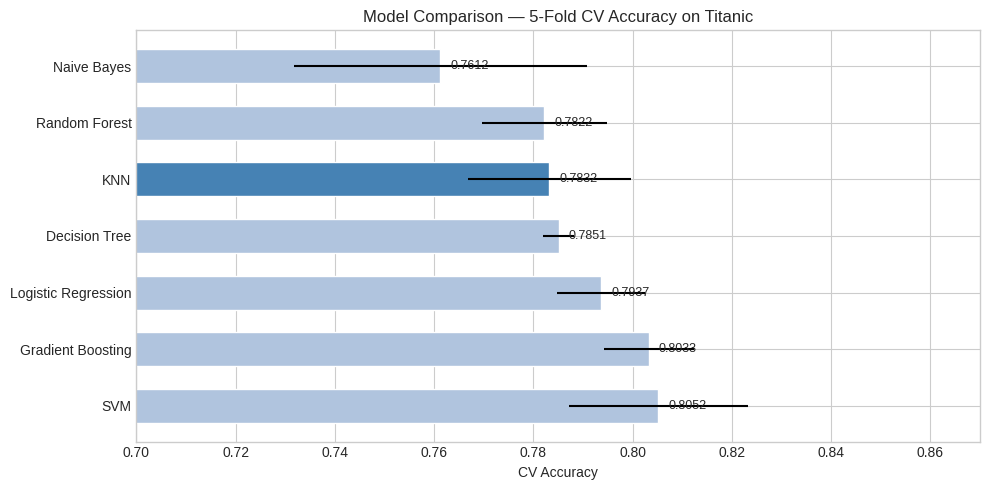

Best model: SVM (CV acc: 0.8052)


In [11]:
# Visualize model comparison
fig, ax = plt.subplots(figsize=(10, 5))

model_names = list(results.keys())
means = [results[n].mean() for n in model_names]
stds  = [results[n].std()  for n in model_names]

order = np.argsort(means)[::-1]
colors = ['steelblue' if i == order[0] else 'lightsteelblue' for i in range(len(order))]

bars = ax.barh([model_names[i] for i in order],
               [means[i] for i in order],
               xerr=[stds[i] for i in order],
               color=[colors[j] for j, i in enumerate(order)],
               edgecolor='white', height=0.6)

for bar, i in zip(bars, order):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{means[i]:.4f}', va='center', fontsize=9)

ax.set_title('Model Comparison — 5-Fold CV Accuracy on Titanic', fontsize=12)
ax.set_xlabel('CV Accuracy')
ax.set_xlim(0.7, 0.87)
plt.tight_layout()
plt.show()

best_model_name = model_names[np.argmax(means)]
print(f'Best model: {best_model_name} (CV acc: {max(means):.4f})')


## 7. Hyperparameter Tuning

In [12]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_dist = {
    'clf__n_estimators':      randint(100, 500),
    'clf__max_depth':         [3, 4, 5, 6, 8, None],
    'clf__min_samples_split': randint(2, 15),
    'clf__min_samples_leaf':  randint(1, 8),
    'clf__max_features':      ['sqrt', 'log2', 0.3, 0.5],
}

rf_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf',  RandomForestClassifier(random_state=42, n_jobs=-1))
])

search = RandomizedSearchCV(
    rf_pipe, param_dist,
    n_iter=30, cv=cv, scoring='accuracy',
    random_state=42, n_jobs=-1
)
search.fit(X_train, y_train)

print(f'Best CV accuracy:  {search.best_score_:.4f}')
print(f'Best parameters:')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')


Best CV accuracy:  0.8109
Best parameters:
  clf__max_depth: None
  clf__max_features: sqrt
  clf__min_samples_leaf: 4
  clf__min_samples_split: 10
  clf__n_estimators: 148


## 8. Final Model Evaluation

In [13]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

best_pipe = search.best_estimator_
y_pred     = best_pipe.predict(X_test)
y_prob     = best_pipe.predict_proba(X_test)[:,1]

print('=== FINAL TEST SET RESULTS ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Died','Survived']))


=== FINAL TEST SET RESULTS ===
Accuracy: 0.8473

              precision    recall  f1-score   support

        Died       0.86      0.90      0.88       162
    Survived       0.83      0.76      0.79       100

    accuracy                           0.85       262
   macro avg       0.84      0.83      0.84       262
weighted avg       0.85      0.85      0.85       262



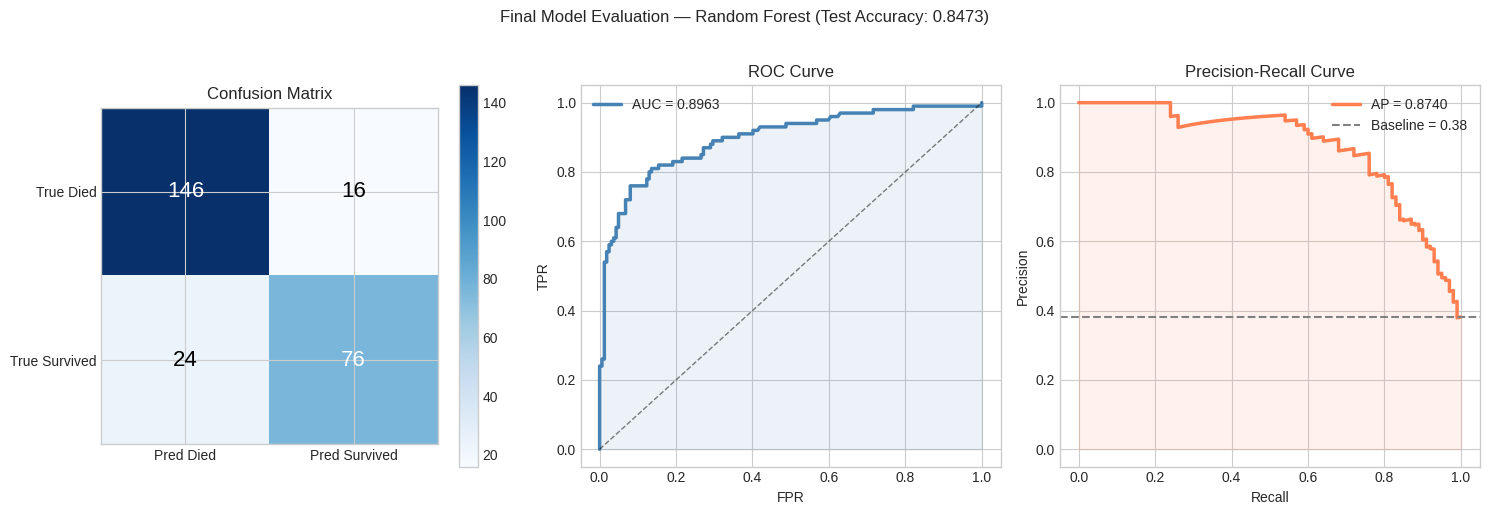

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
im = axes[0].imshow(cm, cmap='Blues')
plt.colorbar(im, ax=axes[0])
axes[0].set_xticks([0,1]); axes[0].set_yticks([0,1])
axes[0].set_xticklabels(['Pred Died','Pred Survived'])
axes[0].set_yticklabels(['True Died','True Survived'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i,j]), ha='center', va='center',
                     fontsize=16, color='white' if cm[i,j]>cm.max()//2 else 'black')
axes[0].set_title('Confusion Matrix', fontsize=12)

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc     = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2.5, label=f'AUC = {roc_auc:.4f}')
axes[1].plot([0,1],[0,1],'k--', linewidth=1, alpha=0.5)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[1].set_title('ROC Curve', fontsize=12)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].legend()

# PR curve
prec, rec, _ = precision_recall_curve(y_test, y_prob)
ap           = average_precision_score(y_test, y_prob)
axes[2].plot(rec, prec, color='coral', linewidth=2.5, label=f'AP = {ap:.4f}')
axes[2].axhline(y_test.mean(), color='gray', linestyle='--', linewidth=1.5,
                label=f'Baseline = {y_test.mean():.2f}')
axes[2].fill_between(rec, prec, alpha=0.1, color='coral')
axes[2].set_title('Precision-Recall Curve', fontsize=12)
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].legend()

plt.suptitle(f'Final Model Evaluation — Random Forest (Test Accuracy: {accuracy_score(y_test, y_pred):.4f})',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


## 9. Feature Importance and Insights

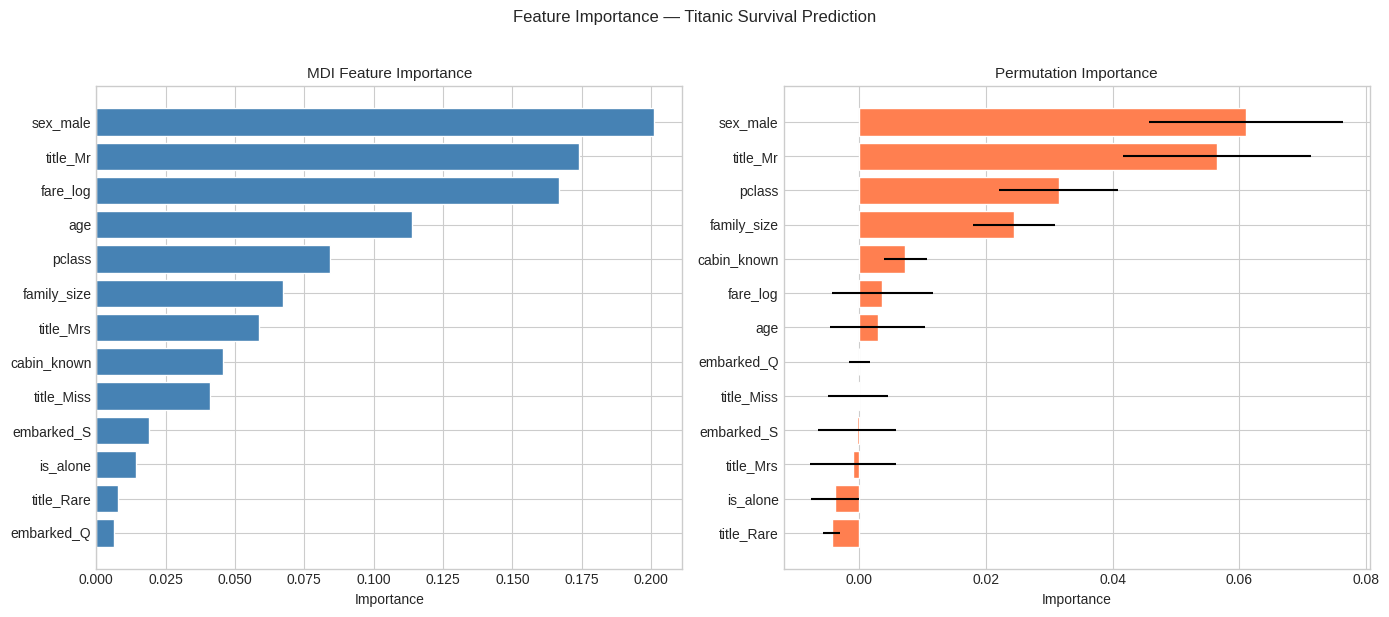

In [15]:
from sklearn.inspection import permutation_importance

# Get feature names after preprocessing
ohe_cats = (best_pipe.named_steps['prep']
            .named_transformers_['cat']
            .named_steps['ohe']
            .get_feature_names_out(categorical_features))

all_feature_names = (numeric_features + binary_features +
                     list(ohe_cats) + ordinal_features)

# MDI importances
rf_model     = best_pipe.named_steps['clf']
importances  = rf_model.feature_importances_
X_test_prep  = best_pipe.named_steps['prep'].transform(X_test)

# Permutation importance
perm = permutation_importance(rf_model, X_test_prep, y_test,
                               n_repeats=20, random_state=42)

# Plot both
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, imp, err, title, color in [
    (axes[0], importances, None, 'MDI Feature Importance', 'steelblue'),
    (axes[1], perm.importances_mean, perm.importances_std, 'Permutation Importance', 'coral'),
]:
    order = np.argsort(imp)[-15:]
    if err is not None:
        ax.barh([all_feature_names[i] for i in order], imp[order],
                xerr=err[order], color=color, edgecolor='white')
    else:
        ax.barh([all_feature_names[i] for i in order], imp[order],
                color=color, edgecolor='white')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Importance')

plt.suptitle('Feature Importance — Titanic Survival Prediction', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


## 10. Key Takeaways

**What the data tells us:**

1. **Gender was the strongest predictor** — women had ~74% survival rate vs ~19% for men.    The 'women and children first' protocol was real and quantifiable.

2. **Passenger class mattered significantly** — 1st class had ~63% survival rate vs ~24% for 3rd class.    Physical location of cabins (closer to lifeboats) + social privilege both played a role.

3. **Title was the most informative engineered feature** — it captures both gender and social status    more precisely than raw Sex + Pclass.

4. **Family size had a non-linear effect** — solo travelers and very large families both had    lower survival rates. Mid-size families (2-4 members) survived best.

5. **Age mattered for children** — children under 12 had notably higher survival rates.    Older passengers had lower survival rates.

**What we learned about the ML process:**

- EDA before modeling reveals patterns that guide feature engineering
- Engineered features (Title, FamilySize, IsAlone) improved performance over raw features
- Random Forest outperformed all other models — tree ensembles handle mixed data types well
- Always use stratified splits for classification to maintain class balance
- Permutation importance and MDI tell similar stories but can differ for correlated features


---

## 👨‍💻 Author

**Himanshu Kumar**

- 🌐 GitHub: [@himanshu231204](https://github.com/himanshu231204)
- 💼 LinkedIn: [himanshu231204](https://www.linkedin.com/in/himanshu231204)
- 🐦 Twitter/X: [@himanshu231204](https://twitter.com/himanshu231204)
- 📧 Email: himanshu231204@gmail.com
